In [2]:
!nvidia-smi

Fri Apr 18 12:28:17 2025       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 525.125.06   Driver Version: 525.125.06   CUDA Version: 12.0     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  NVIDIA A100 80G...  On   | 00000000:17:00.0 Off |                    0 |
| N/A   30C    P0    44W / 300W |      0MiB / 81920MiB |      0%      Default |
|                               |                      |             Disabled |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

### 导入库

In [3]:
import pandas as pd
import numpy as np
from datetime import datetime

### 读入数据

In [4]:
# 从上到下样本逐渐增多
Australia = pd.read_csv("./statlog australian credit approval 690行/australian.dat", sep='\s+',header=None)
German = pd.read_csv("./German/german.data", sep='\s+',header=None)
Taiwan = pd.read_csv('./Default of Credit Card Clients Dataset （台湾）30000行/UCI_Credit_Card.csv')
Platform = pd.read_csv('./预测用户贷款是否违约/train.csv')
# Bank_bill = pd.read_csv('./银行征信数据/bill_detail_train.txt',sep=',',header=None)

In [5]:
# Bank_detail = pd.read_csv('./银行征信数据/bank_detail_train.txt',sep=',',header=None)
# Bank_browse = pd.read_csv('./银行征信数据/browse_history_train.txt',sep=',',header=None)
# Bank_tag = pd.read_csv('./银行征信数据/overdue_train.txt',sep=',',header=None)
# Bank_user = pd.read_csv('./银行征信数据/user_info_train.txt',sep=',',header=None)
# Bank_loan = pd.read_csv('./银行征信数据/loan_time_train.txt',sep=',',header=None)

#### 基本数据统计

##### 是否平衡

In [6]:
print(Australia[14].value_counts())
Australia_major = Australia[14].value_counts()[0]
German.iloc[:,-1] = [label - 1 for label in German.iloc[:,-1]]
print(German[20].value_counts())
German_major = German[20].value_counts()[0]
print(Taiwan['default.payment.next.month'].value_counts())
Taiwan_major = Taiwan['default.payment.next.month'].value_counts()[0]
print(Platform['isDefault'].value_counts())
Platform_major = Platform['isDefault'].value_counts()[0]

0    383
1    307
Name: 14, dtype: int64
0    700
1    300
Name: 20, dtype: int64
0    23364
1     6636
Name: default.payment.next.month, dtype: int64
0    640390
1    159610
Name: isDefault, dtype: int64


##### 是否有缺失值

In [7]:
print(Australia.isnull().sum())

0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
14    0
dtype: int64


In [8]:
print(German.isnull().sum())

0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
14    0
15    0
16    0
17    0
18    0
19    0
20    0
dtype: int64


In [9]:
print(Taiwan.isnull().sum())

ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64


In [10]:
print(Platform.isnull().sum())

id                        0
loanAmnt                  0
term                      0
interestRate              0
installment               0
grade                     0
subGrade                  0
employmentTitle           1
employmentLength      46799
homeOwnership             0
annualIncome              0
verificationStatus        0
issueDate                 0
isDefault                 0
purpose                   0
postCode                  1
regionCode                0
dti                     239
delinquency_2years        0
ficoRangeLow              0
ficoRangeHigh             0
openAcc                   0
pubRec                    0
pubRecBankruptcies      405
revolBal                  0
revolUtil               531
totalAcc                  0
initialListStatus         0
applicationType           0
earliesCreditLine         0
title                     1
policyCode                0
n0                    40270
n1                    40270
n2                    40270
n3                  

### 数据格式统一

#### 分开特征和标签

In [11]:
Australia_X = Australia.iloc[:, :14]
Australia_y = Australia.iloc[:, 14]
German_X = German.iloc[:,:-1]
German_y = German.iloc[:,-1]
Taiwan_X = Taiwan.iloc[:,:-1]
Taiwan_y = Taiwan.iloc[:,-1]
Platform_X = Platform.drop('isDefault', axis=1)
Platform_y = Platform['isDefault']

In [12]:
del Taiwan_X['ID']
del Platform_X['id']
del Platform_X['regionCode']

#### 对于序数属性的处理/二元标称属性

##### German

第一列支票账户余额区间转换为数字，其中没有支票账户A14和A12合并

In [13]:
German_X[0]= German_X[0].str[-1:].astype(int)
German_X[0] = German_X[0].replace(4,2)
German_X[0].value_counts() 

2    663
1    274
3     63
Name: 0, dtype: int64

第三列信用历史转换为数字

In [14]:
German_X[2]= German_X[2].str[-1:].astype(int)
German_X[2].value_counts() 

2    530
4    293
3     88
1     49
0     40
Name: 2, dtype: int64

第四列贷款用途，由于类别太多，直接使用独热编码会使得数据很稀疏，因此A40-44归为家具，A45为维修，A46-A48为教育，A49为生意，A50为其他

In [15]:
German_X[3]= German_X[3].str[-2:].astype(int)
German_X[3] = German_X[3].replace({40:0,41: 0, 42: 0,43: 0,44: 0,45: 1,46:2,47:2,48:2,49:3,10:4})
German_X[3].value_counts() 

0    810
3     97
2     59
1     22
4     12
Name: 3, dtype: int64

第六列存款，将unknown设置为0，因为没有记录绝大部分是没有存款

In [16]:
German_X[5]= German_X[5].str[-1:].astype(int)
German_X[5] = German_X[5].replace(5,0)
German_X[5].value_counts() 

1    603
0    183
2    103
3     63
4     48
Name: 5, dtype: int64

第七列目前工作从几年前开始，将unemployed设置为1

In [17]:
German_X[6]= German_X[6].str[-1:].astype(int)
German_X[6].value_counts() 

3    339
5    253
4    174
2    172
1     62
Name: 6, dtype: int64

第十二列，资产种类隐含资产多少的关系

In [18]:
German_X[11]= German_X[11].str[-1:].astype(int)
German_X[11].value_counts() 

3    332
1    282
2    232
4    154
Name: 11, dtype: int64

第十七列，就业情况，隐含偿还能力

In [19]:
German_X[16]= German_X[16].str[-1:].astype(int)
German_X[16].value_counts() 

3    630
2    200
4    148
1     22
Name: 16, dtype: int64

第十九列和二十列，二元分类变量

In [20]:
German_X[18]= German_X[18].str[-1:].astype(int)
German_X[18].value_counts() 
German_X[19]= German_X[19].str[-1:].astype(int)
German_X[19].value_counts() 

1    963
2     37
Name: 19, dtype: int64

##### Platform

subGrade等级变成连续型变量

In [21]:
Platform_X = Platform_X.drop(['grade'],axis=1)

In [22]:
Platform_X.columns

Index(['loanAmnt', 'term', 'interestRate', 'installment', 'subGrade',
       'employmentTitle', 'employmentLength', 'homeOwnership', 'annualIncome',
       'verificationStatus', 'issueDate', 'purpose', 'postCode', 'dti',
       'delinquency_2years', 'ficoRangeLow', 'ficoRangeHigh', 'openAcc',
       'pubRec', 'pubRecBankruptcies', 'revolBal', 'revolUtil', 'totalAcc',
       'initialListStatus', 'applicationType', 'earliesCreditLine', 'title',
       'policyCode', 'n0', 'n1', 'n2', 'n3', 'n4', 'n5', 'n6', 'n7', 'n8',
       'n9', 'n10', 'n11', 'n12', 'n13', 'n14'],
      dtype='object')

In [23]:
Platform_X['subGrade'] = Platform_X['subGrade'].str[0].apply(lambda x: ord(x) - ord('A'))*5+Platform_X['subGrade'].str[1].astype(int)

In [24]:
Platform_X['subGrade'].value_counts()

11    50763
9     49516
10    48965
8     48600
12    47068
13    44751
14    44272
7     44227
6     42382
15    40264
5     38045
4     30928
16    30538
17    26528
1     25909
18    23410
3     22655
2     22124
19    21139
20    17838
21    14064
22    12746
23    10925
24     9273
25     8653
26     5925
27     4340
28     3577
29     2859
30     2352
31     1759
32     1231
33      978
34      751
35      645
Name: subGrade, dtype: int64

In [25]:
Platform_X['employmentLength']=Platform_X['employmentLength'].astype(str).replace({'10+ years':20,'< 1 year':0.5,'1 year':1,'2 years':2,'3 years':3,'4 years':4,'5 years':5,'6 years':6,'7 years':7,'8 years':8,'9 years':9}).astype(float)

In [26]:
Platform_X['employmentLength'].value_counts()

20.0    262753
2.0      72358
0.5      64237
3.0      64152
1.0      52489
5.0      50102
4.0      47985
6.0      37254
8.0      36192
7.0      35407
9.0      30272
Name: employmentLength, dtype: int64

发生时间，其实可以结合是否同一用户上一次已违约来生成新一列属性，但是我现在直接把他删了，因为对模型优秀程度比较似乎没有什么帮助

In [27]:
Platform_X = Platform_X.drop(['issueDate'],axis=1)

最早信用时间，直接使用年份

In [28]:
Platform_X['earliesCreditLine']=Platform_X['earliesCreditLine'].str[4:].astype(int)

In [29]:
Platform_X.dtypes

loanAmnt              float64
term                    int64
interestRate          float64
installment           float64
subGrade                int64
employmentTitle       float64
employmentLength      float64
homeOwnership           int64
annualIncome          float64
verificationStatus      int64
purpose                 int64
postCode              float64
dti                   float64
delinquency_2years    float64
ficoRangeLow          float64
ficoRangeHigh         float64
openAcc               float64
pubRec                float64
pubRecBankruptcies    float64
revolBal              float64
revolUtil             float64
totalAcc              float64
initialListStatus       int64
applicationType         int64
earliesCreditLine       int64
title                 float64
policyCode            float64
n0                    float64
n1                    float64
n2                    float64
n3                    float64
n4                    float64
n5                    float64
n6        

#### 对于标称属性的处理-把一个标称属性分成多栏

##### German

第九列性别及是否单身，分成性别一栏+单身一栏

In [30]:
#性别,0为女性，1为男性
German_X[20] =German_X[8].apply(lambda x: 1 if x == 'A91' or x == 'A93' or x == 'A94' else 0)
German_X[20].value_counts()

1    690
0    310
Name: 20, dtype: int64

In [31]:
#单身为0，非单身为1
German_X[21] =German_X[8].apply(lambda x: 0 if x == 'A93' or x == 'A95' else 1)
German_X[21].value_counts()

0    548
1    452
Name: 21, dtype: int64

第十列，是否有债权人/担保人

In [32]:
German_X.columns

Int64Index([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
            19, 20, 21],
           dtype='int64')

In [33]:
dummies = pd.get_dummies(German_X[9],dummy_na=False)
German_X = pd.concat([German_X, dummies], axis=1)
German_X.columns

Index([     0,      1,      2,      3,      4,      5,      6,      7,      8,
            9,     10,     11,     12,     13,     14,     15,     16,     17,
           18,     19,     20,     21, 'A101', 'A102', 'A103'],
      dtype='object')

第十四列，是否有其他分期付款计划

In [34]:
dummies = pd.get_dummies(German_X[13],dummy_na=False)
German_X = pd.concat([German_X, dummies], axis=1)
German_X.columns

Index([     0,      1,      2,      3,      4,      5,      6,      7,      8,
            9,     10,     11,     12,     13,     14,     15,     16,     17,
           18,     19,     20,     21, 'A101', 'A102', 'A103', 'A141', 'A142',
       'A143'],
      dtype='object')

第十五列，住房类型

In [35]:
dummies = pd.get_dummies(German_X[14],dummy_na=False)
German_X = pd.concat([German_X, dummies], axis=1)
German_X.columns

Index([     0,      1,      2,      3,      4,      5,      6,      7,      8,
            9,     10,     11,     12,     13,     14,     15,     16,     17,
           18,     19,     20,     21, 'A101', 'A102', 'A103', 'A141', 'A142',
       'A143', 'A151', 'A152', 'A153'],
      dtype='object')

In [36]:
German_X = German_X.drop(German_X.columns[[8, 9, 13, 14]], axis=1)
German_X.columns

Index([     0,      1,      2,      3,      4,      5,      6,      7,     10,
           11,     12,     15,     16,     17,     18,     19,     20,     21,
       'A101', 'A102', 'A103', 'A141', 'A142', 'A143', 'A151', 'A152', 'A153'],
      dtype='object')

In [37]:
German_X.columns = range(German_X.shape[1])

In [38]:
German_X.columns

RangeIndex(start=0, stop=27, step=1)

#### 对于缺失值的处理

缺失值都不是标签，可以进行填充或者标记，而不直接删除数据；把分类太多的删除

In [39]:
Platform_X['employmentTitle']=Platform_X['employmentTitle'].fillna(Platform_X['employmentTitle'].mean())

Platform_X['employmentLength']=Platform_X['employmentLength'].fillna(Platform_X['employmentLength'].mean())

# Platform_X['postCode']=Platform_X['postCode'].fillna(Platform_X['postCode'].mode()[0])
Platform_X.drop(['postCode'], axis=1, inplace=True)
Platform_X.drop(['title'], axis=1, inplace=True)

Platform_X['dti']=Platform_X['dti'].fillna(Platform_X['dti'].mean())

Platform_X['pubRecBankruptcies']=Platform_X['pubRecBankruptcies'].fillna(Platform_X['pubRecBankruptcies'].mean())

Platform_X['revolUtil']=Platform_X['revolUtil'].fillna(Platform_X['revolUtil'].mean())

# Platform_X['title']=Platform_X['title'].fillna(Platform_X['title'].mode()[0])

Platform_X['n0']=Platform_X['n0'].fillna(Platform_X['n0'].mean())
Platform_X['n1']=Platform_X['n1'].fillna(Platform_X['n1'].mean())
Platform_X['n2']=Platform_X['n2'].fillna(Platform_X['n2'].mean())
Platform_X['n3']=Platform_X['n3'].fillna(Platform_X['n3'].mean())
Platform_X['n4']=Platform_X['n4'].fillna(Platform_X['n4'].mean())
Platform_X['n5']=Platform_X['n5'].fillna(Platform_X['n5'].mean())
Platform_X['n6']=Platform_X['n6'].fillna(Platform_X['n6'].mean())
Platform_X['n7']=Platform_X['n7'].fillna(Platform_X['n7'].mean())
Platform_X['n8']=Platform_X['n8'].fillna(Platform_X['n8'].mean())
Platform_X['n9']=Platform_X['n9'].fillna(Platform_X['n9'].mean())
Platform_X['n10']=Platform_X['n10'].fillna(Platform_X['n10'].mean())
Platform_X['n11']=Platform_X['n11'].fillna(Platform_X['n11'].mean())
Platform_X['n12']=Platform_X['n12'].fillna(Platform_X['n12'].mean())
Platform_X['n13']=Platform_X['n13'].fillna(Platform_X['n13'].mean())
Platform_X['n14']=Platform_X['n14'].fillna(Platform_X['n14'].mean())

In [40]:
Platform_X.isnull().sum()

loanAmnt              0
term                  0
interestRate          0
installment           0
subGrade              0
employmentTitle       0
employmentLength      0
homeOwnership         0
annualIncome          0
verificationStatus    0
purpose               0
dti                   0
delinquency_2years    0
ficoRangeLow          0
ficoRangeHigh         0
openAcc               0
pubRec                0
pubRecBankruptcies    0
revolBal              0
revolUtil             0
totalAcc              0
initialListStatus     0
applicationType       0
earliesCreditLine     0
policyCode            0
n0                    0
n1                    0
n2                    0
n3                    0
n4                    0
n5                    0
n6                    0
n7                    0
n8                    0
n9                    0
n10                   0
n11                   0
n12                   0
n13                   0
n14                   0
dtype: int64

#### 不平衡的处理

过采样比欠采样效果更佳 https://ieeexplore.ieee.org/abstract/document/9078901

新过采样方法 https://www.mdpi.com/2073-8994/13/2/194 

##### SMOTE

imblearn 提供的 SMOTENC 支持混合类型的数据，数值特征使用插值，分类特征随机采样。

In [41]:
from sklearn.neighbors import NearestNeighbors
 
def SMOTE(X, y, N, k=5):
    """
    合成少数类过采样技术（SMOTE）
    参数：
        X (numpy数组): 包含数据点的特征矩阵。
        y (numpy数组): 对应的标签数组（多数类为0，少数类为1）。
        N (int): 生成的合成样本数量。
        k (int, 可选): 考虑的最近邻居数量，默认为5。
    返回：
        X_synthetic (numpy数组): 包含生成样本的合成特征矩阵。
        y_synthetic (numpy数组): 合成样本对应的标签数组。
    """
 
    # 分离多数类和少数类样本
    X_majority = X[y == 0]
    X_minority = X[y == 1]
 
    # 计算每个少数类样本需要生成的合成样本数量
    N_per_sample = N // len(X_minority)
 
    # 如果k大于少数样本数量，则将其减少到可能的最大值
    k = min(k, len(X_minority) - 1)
 
    # 初始化列表以存储合成样本和相应的标签
    synthetic_samples = []
    synthetic_labels = []
 
    # 在少数类样本上拟合k近邻
    knn = NearestNeighbors(n_neighbors=k)
    knn.fit(X_minority)
 
    for minority_sample in X_minority:
        # 查找当前少数类样本的k个最近邻居
        _, indices = knn.kneighbors(minority_sample.reshape(1, -1), n_neighbors=k)
 
        # 随机选择k个邻居并创建合成样本
        for _ in range(N_per_sample):
            # 选出邻居
            neighbor_index = np.random.choice(indices[0])
            neighbor = X_minority[neighbor_index]
 
            # 计算当前少数类样本和邻居之间的差异
            difference = neighbor - minority_sample
 
            # 生成一个0到1之间的随机数
            alpha = np.random.random()
 
            # 创建一个合成样本作为少数类样本和邻居的线性组合
            synthetic_sample = minority_sample + alpha * difference
 
            # 将合成样本及其标签追加到列表中
            synthetic_samples.append(synthetic_sample)
            synthetic_labels.append(1) 
 
    # 将列表转换为numpy数组
    X_synthetic = np.array(synthetic_samples)
    y_synthetic = np.array(synthetic_labels)
 
    # 将原始多数类样本与合成样本合并
    X_balanced = np.concatenate((X_majority, X_synthetic), axis=0)
    y_balanced = np.concatenate((np.zeros(len(X_majority)), y_synthetic), axis=0)
 
    return X_balanced, y_balanced

Australia

In [42]:
from imblearn.over_sampling import SMOTENC
#确定分类特征
categorical_features = [0,2,3,4,5,7,8,9,10,11,13]
# 初始化 SMOTENC
smote_nc = SMOTENC(categorical_features=categorical_features, random_state=2)
# 执行过采样
Australia_X_res, Australia_y_res = smote_nc.fit_resample(Australia_X, Australia_y)

# 转换为 DataFrame 查看结果
Australia_X_res = pd.DataFrame(Australia_X_res, columns=Australia_X.columns)
# Australia_y_res = pd.DataFrame(Australia_y_res)

In [43]:
Australia_y_res.value_counts()

0    383
1    383
Name: 14, dtype: int64

German

In [44]:
German_X.iloc[0]

0        1
1        6
2        4
3        0
4     1169
5        0
6        5
7        4
8        4
9        1
10      67
11       2
12       3
13       1
14       2
15       1
16       1
17       0
18       1
19       0
20       0
21       0
22       0
23       1
24       0
25       1
26       0
Name: 0, dtype: int64

In [45]:
#确定分类特征
categorical_features = [0,3,5,9,11,13,14,15,16,17,18,19,20,21,22,23,24,25,26]

# 初始化 SMOTENC
smote_nc = SMOTENC(categorical_features=categorical_features, random_state=2)
# 执行过采样
German_X_res, German_y_res = smote_nc.fit_resample(German_X, German_y)

# 转换为 DataFrame 查看结果
German_X_res = pd.DataFrame(German_X_res, columns=German_X.columns)
# German_y_res = pd.DataFrame(German_y_res)

In [46]:
German_y_res.value_counts()

0    700
1    700
Name: 20, dtype: int64

Taiwan

In [47]:
Taiwan_X

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,20000.0,2,2,1,24,2,2,-1,-1,-2,...,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0
1,120000.0,2,2,2,26,-1,2,0,0,0,...,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0
2,90000.0,2,2,2,34,0,0,0,0,0,...,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0
3,50000.0,2,2,1,37,0,0,0,0,0,...,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0
4,50000.0,1,2,1,57,-1,0,-1,0,0,...,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000.0,1,3,1,39,0,0,0,0,0,...,208365.0,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0
29996,150000.0,1,3,2,43,-1,-1,-1,-1,0,...,3502.0,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0
29997,30000.0,1,2,2,37,4,3,2,-1,0,...,2758.0,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0
29998,80000.0,1,3,1,41,1,-1,0,0,0,...,76304.0,52774.0,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0


In [48]:
#确定分类特征
categorical_features = ['SEX','MARRIAGE']

# 初始化 SMOTENC
smote_nc = SMOTENC(categorical_features=categorical_features, random_state=2)
# 执行过采样
Taiwan_X_res, Taiwan_y_res = smote_nc.fit_resample(Taiwan_X, Taiwan_y)

# 转换为 DataFrame 查看结果
Taiwan_X_res = pd.DataFrame(Taiwan_X_res, columns=Taiwan_X.columns)
# Taiwan_y_res = pd.DataFrame(Taiwan_y_res)

In [49]:
Taiwan_y_res.value_counts()

1    23364
0    23364
Name: default.payment.next.month, dtype: int64

Platform

In [50]:
Platform_X.iloc[0]

loanAmnt               35000.00
term                       5.00
interestRate              19.52
installment              917.97
subGrade                  22.00
employmentTitle          320.00
employmentLength           2.00
homeOwnership              2.00
annualIncome          110000.00
verificationStatus         2.00
purpose                    1.00
dti                       17.05
delinquency_2years         0.00
ficoRangeLow             730.00
ficoRangeHigh            734.00
openAcc                    7.00
pubRec                     0.00
pubRecBankruptcies         0.00
revolBal               24178.00
revolUtil                 48.90
totalAcc                  27.00
initialListStatus          0.00
applicationType            0.00
earliesCreditLine       2001.00
policyCode                 1.00
n0                         0.00
n1                         2.00
n2                         2.00
n3                         2.00
n4                         4.00
n5                         9.00
n6      

In [51]:
# #确定分类特征
# categorical_features = ['homeOwnership','verificationStatus','purpose','initialListStatus','policyCode']

# # 初始化 SMOTENC
# smote_nc = SMOTENC(categorical_features=categorical_features, random_state=2)
# # 执行过采样
# Platform_X_res, Platform_y_res = smote_nc.fit_resample(Platform_X, Platform_y)

# # 转换为 DataFrame 查看结果
# Platform_X_res = pd.DataFrame(Platform_X_res, columns=Platform_X.columns)
# # Platform_y_res = pd.DataFrame(Platform_y_res)

In [52]:
# Platform_X_res.to_csv('Platform_X_res.csv',index=False)
# Platform_y_res.to_csv('Platform_y_res.csv',index=False)

In [53]:
Platform_X_res=pd.read_csv('Platform_X_res.csv')
Platform_y_res=pd.read_csv('Platform_y_res.csv')

In [63]:
# Australia_X_res.to_csv('Australia_X_res.csv',index=False)
# Australia_y_res.to_csv('Australia_y_res.csv',index=False)

In [64]:
# German_X_res.to_csv('German_X_res.csv',index=False)
# German_y_res.to_csv('German_y_res.csv',index=False)

In [65]:
# Taiwan_X_res.to_csv('Taiwan_X_res.csv',index=False)
# Taiwan_y_res.to_csv('Taiwan_y_res.csv',index=False)

### Baseline

#### 逻辑回归

In [54]:
# 导入必要的库
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'average_precision']

def logistic_regression(X, y, cv=5, max_iter=5000,scoring = scoring,random_state=42):
    

    # 创建逻辑回归模型
    model = LogisticRegression(max_iter=max_iter,random_state=random_state)

    results = cross_validate(model, X, y, cv=cv, scoring=scoring)
    print(f"平均准确率: {results['test_accuracy'].mean():.2f}")
    print(f"平均精确率: {results['test_precision'].mean():.2f}")
    print(f"平均召回率: {results['test_recall'].mean():.2f}")
    print(f"平均F1得分: {results['test_f1'].mean():.2f}")
    print(f"平均AUC-ROC: {results['test_roc_auc'].mean():.2f}")
    print(f"平均AUC-PR: {results['test_average_precision'].mean():.2f}")
    # # 训练模型
    # model.fit(X_train, y_train)

    # # 测试模型
    # y_pred = model.predict(X_test)

    # # 评估模型
    # accuracy = accuracy_score(y_test, y_pred)
    # conf_matrix = confusion_matrix(y_test, y_pred)
    # report = classification_report(y_test, y_pred)

    # # 打印结果
    # print("模型准确率:", accuracy)
    # print("\n混淆矩阵:\n", conf_matrix)
    # print("\n分类报告:\n", report)


##### Australia

In [55]:
start = datetime.now()
logistic_regression(Australia_X,Australia_y,max_iter=9000)
end = datetime.now()
print(f"运行时间: {(end - start)}")

平均准确率: 0.86
平均精确率: 0.84
平均召回率: 0.86
平均F1得分: 0.85
平均AUC-ROC: 0.93
平均AUC-PR: 0.92
运行时间: 0:00:02.530995


In [56]:
start = datetime.now()
logistic_regression(Australia_X_res,Australia_y_res,max_iter=9000)
end = datetime.now()
print(f"平均运行时间: {(end - start)}")

平均准确率: 0.87
平均精确率: 0.86
平均召回率: 0.90
平均F1得分: 0.88
平均AUC-ROC: 0.94
平均AUC-PR: 0.94
平均运行时间: 0:00:01.322535


##### German

In [57]:
start = datetime.now()
logistic_regression(German_X,German_y,max_iter=9000)
end = datetime.now()
print(f"平均运行时间: {(end - start)}")

平均准确率: 0.74
平均精确率: 0.63
平均召回率: 0.38
平均F1得分: 0.47
平均AUC-ROC: 0.74
平均AUC-PR: 0.56
平均运行时间: 0:08:04.897400


In [58]:
start = datetime.now()
logistic_regression(German_X_res,German_y_res,max_iter=9000)
end = datetime.now()
print(f"平均运行时间: {(end - start)}")

平均准确率: 0.76
平均精确率: 0.78
平均召回率: 0.67
平均F1得分: 0.68
平均AUC-ROC: 0.87
平均AUC-PR: 0.86
平均运行时间: 0:05:53.814672


##### Taiwan

In [59]:
start = datetime.now()
logistic_regression(Taiwan_X,Taiwan_y,max_iter=9000)
end = datetime.now()
print(f"平均运行时间: {(end - start)}")

/nfs/home/4001_tengyishu/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/nfs/home/4001_tengyishu/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linea

平均准确率: 0.81
平均精确率: 0.71
平均召回率: 0.24
平均F1得分: 0.36
平均AUC-ROC: 0.72
平均AUC-PR: 0.50
平均运行时间: 0:21:50.049775


/nfs/home/4001_tengyishu/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [60]:
start = datetime.now()
logistic_regression(Taiwan_X_res,Taiwan_y_res,max_iter=9000)
end = datetime.now()
print(f"平均运行时间: {(end - start)}")

/nfs/home/4001_tengyishu/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/nfs/home/4001_tengyishu/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linea

平均准确率: 0.68
平均精确率: 0.68
平均召回率: 0.65
平均F1得分: 0.67
平均AUC-ROC: 0.74
平均AUC-PR: 0.74
平均运行时间: 0:21:58.308158


/nfs/home/4001_tengyishu/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


##### Platform

In [61]:
start = datetime.now()
logistic_regression(Platform_X,Platform_y,max_iter=9000)
end = datetime.now()
print(f"平均运行时间: {(end - start)}")

/nfs/home/4001_tengyishu/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/nfs/home/4001_tengyishu/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linea

平均准确率: 0.80
平均精确率: 0.52
平均召回率: 0.07
平均F1得分: 0.13
平均AUC-ROC: 0.71
平均AUC-PR: 0.37
平均运行时间: 1:31:32.043819


In [62]:
start = datetime.now()
logistic_regression(Platform_X_res,Platform_y_res,max_iter=9000)
end = datetime.now()
print(f"平均运行时间: {(end - start)}")

/nfs/home/4001_tengyishu/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/nfs/home/4001_tengyishu/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/nfs/home/4001_tengyishu/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected

平均准确率: 0.67
平均精确率: 0.67
平均召回率: 0.69
平均F1得分: 0.68
平均AUC-ROC: 0.73
平均AUC-PR: 0.69
平均运行时间: 1:49:58.003436


#### 决策树

In [63]:
# 导入必要的库
from sklearn.tree import DecisionTreeClassifier

# # 构建决策树分类器
# model = DecisionTreeClassifier(random_state=42)

# # 使用训练集数据训练模型
# model.fit(X_train, y_train)

# # 使用测试集数据进行预测
# y_pred = model.predict(X_test)

# # 评估模型
# accuracy = accuracy_score(y_test, y_pred)
# conf_matrix = confusion_matrix(y_test, y_pred)
# report = classification_report(y_test, y_pred)

# print("模型准确率:", accuracy)
# print("\n混淆矩阵:\n", conf_matrix)
# print("\n分类报告:\n", report)

def descision_tree(X, y,cv=5,scoring = scoring,random_state=42,max_depth=5):

    # 创建逻辑回归模型
    model = DecisionTreeClassifier(random_state=random_state,max_depth = max_depth)

    results = cross_validate(model, X, y, cv=cv, scoring=scoring)
    print(f"平均准确率: {results['test_accuracy'].mean():.2f}")
    print(f"平均精确率: {results['test_precision'].mean():.2f}")
    print(f"平均召回率: {results['test_recall'].mean():.2f}")
    print(f"平均F1得分: {results['test_f1'].mean():.2f}")
    print(f"平均AUC-ROC: {results['test_roc_auc'].mean():.2f}")
    print(f"平均AUC-PR: {results['test_average_precision'].mean():.2f}")

##### Australia

In [64]:
start = datetime.now()
descision_tree(Australia_X,Australia_y,max_depth=20)
end = datetime.now()
print(f"平均运行时间: {(end - start)}")

平均准确率: 0.81
平均精确率: 0.78
平均召回率: 0.78
平均F1得分: 0.78
平均AUC-ROC: 0.80
平均AUC-PR: 0.71
平均运行时间: 0:00:00.470938


In [65]:
start = datetime.now()
descision_tree(Australia_X_res,Australia_y_res,max_depth=20)
end = datetime.now()
print(f"平均运行时间: {(end - start)}")

平均准确率: 0.84
平均精确率: 0.84
平均召回率: 0.86
平均F1得分: 0.85
平均AUC-ROC: 0.84
平均AUC-PR: 0.79
平均运行时间: 0:00:00.060342


##### German

In [66]:
start = datetime.now()
descision_tree(German_X,German_y,max_depth=20)
end = datetime.now()
print(f"平均运行时间: {(end - start)}")

平均准确率: 0.67
平均精确率: 0.45
平均召回率: 0.49
平均F1得分: 0.47
平均AUC-ROC: 0.62
平均AUC-PR: 0.38
平均运行时间: 0:00:00.071754


In [67]:
start = datetime.now()
descision_tree(German_X_res,German_y_res,max_depth=20)
end = datetime.now()
print(f"平均运行时间: {(end - start)}")

平均准确率: 0.72
平均精确率: 0.72
平均召回率: 0.70
平均F1得分: 0.70
平均AUC-ROC: 0.72
平均AUC-PR: 0.67
平均运行时间: 0:00:00.083688


##### Taiwan

In [68]:
start = datetime.now()
descision_tree(Taiwan_X,Taiwan_y,max_depth=50)
end = datetime.now()
print(f"平均运行时间: {(end - start)}")

平均准确率: 0.73
平均精确率: 0.39
平均召回率: 0.42
平均F1得分: 0.40
平均AUC-ROC: 0.62
平均AUC-PR: 0.29
平均运行时间: 0:00:02.714540


In [69]:
start = datetime.now()
descision_tree(Taiwan_X_res,Taiwan_y_res,max_depth=50)
end = datetime.now()
print(f"平均运行时间: {(end - start)}")

平均准确率: 0.75
平均精确率: 0.74
平均召回率: 0.77
平均F1得分: 0.75
平均AUC-ROC: 0.75
平均AUC-PR: 0.69
平均运行时间: 0:00:03.850867


##### Platform

In [70]:
start = datetime.now()
descision_tree(Platform_X,Platform_y,max_depth=50)
end = datetime.now()
print(f"平均运行时间: {(end - start)}")

平均准确率: 0.70
平均精确率: 0.28
平均召回率: 0.30
平均F1得分: 0.29
平均AUC-ROC: 0.55
平均AUC-PR: 0.22
平均运行时间: 0:01:36.213742


In [71]:
start = datetime.now()
descision_tree(Platform_X_res,Platform_y_res,max_depth=50)
end = datetime.now()
print(f"平均运行时间: {(end - start)}")

平均准确率: 0.78
平均精确率: 0.76
平均召回率: 0.77
平均F1得分: 0.73
平均AUC-ROC: 0.78
平均AUC-PR: 0.72
平均运行时间: 0:02:54.840063


#### Xgboost

In [72]:
# 导入必要的库
from xgboost import XGBClassifier

# # 假设你已经有了 `Australia_X` 和 `Australia_y`
# X = Australia_X  # 特征数据 (100个样本，2个特征)
# y = Australia_y  # 标签数据 (分类标签)

# # 分割数据集为训练集和测试集 (80% 训练集，20% 测试集)
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # 构建XGBoost分类器
# model = XGBClassifier(eval_metric='logloss')

# # 使用训练集数据训练模型
# model.fit(X_train, y_train)

# # 使用测试集数据进行预测
# y_pred = model.predict(X_test)

# # 评估模型
# accuracy = accuracy_score(y_test, y_pred)
# conf_matrix = confusion_matrix(y_test, y_pred)
# report = classification_report(y_test, y_pred)

# print("模型准确率:", accuracy)
# print("\n混淆矩阵:\n", conf_matrix)
# print("\n分类报告:\n", report)

def xgboost(X, y,cv=5,scoring = scoring,random_state=42,n_estimators=1000):

    # 创建逻辑回归模型
    model = XGBClassifier(eval_metric='logloss',random_state = random_state,n_estimators=n_estimators)

    results = cross_validate(model, X, y, cv=cv, scoring=scoring)
    print(f"平均准确率: {results['test_accuracy'].mean():.2f}")
    print(f"平均精确率: {results['test_precision'].mean():.2f}")
    print(f"平均召回率: {results['test_recall'].mean():.2f}")
    print(f"平均F1得分: {results['test_f1'].mean():.2f}")
    print(f"平均AUC-ROC: {results['test_roc_auc'].mean():.2f}")
    print(f"平均AUC-PR: {results['test_average_precision'].mean():.2f}")

/nfs/home/4001_tengyishu/anaconda3/lib/python3.11/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


##### Australia

In [73]:
start = datetime.now()
xgboost(Australia_X,Australia_y,n_estimators=1000)
end = datetime.now()
print(f"平均运行时间: {(end - start)}")

平均准确率: 0.87
平均精确率: 0.86
平均召回率: 0.86
平均F1得分: 0.86
平均AUC-ROC: 0.93
平均AUC-PR: 0.90
平均运行时间: 0:00:01.356102


In [74]:
start = datetime.now()
xgboost(Australia_X_res,Australia_y_res,n_estimators=1000)
end = datetime.now()
print(f"平均运行时间: {(end - start)}")

平均准确率: 0.89
平均精确率: 0.88
平均召回率: 0.90
平均F1得分: 0.89
平均AUC-ROC: 0.94
平均AUC-PR: 0.93
平均运行时间: 0:00:01.115021


##### German

In [75]:
start = datetime.now()
xgboost(German_X,German_y,n_estimators=1000)
end = datetime.now()
print(f"平均运行时间: {(end - start)}")

平均准确率: 0.73
平均精确率: 0.57
平均召回率: 0.48
平均F1得分: 0.52
平均AUC-ROC: 0.74
平均AUC-PR: 0.57
平均运行时间: 0:00:01.601787


In [76]:
start = datetime.now()
xgboost(German_X_res,German_y_res,n_estimators=1000)
end = datetime.now()
print(f"平均运行时间: {(end - start)}")

平均准确率: 0.79
平均精确率: 0.81
平均召回率: 0.74
平均F1得分: 0.75
平均AUC-ROC: 0.88
平均AUC-PR: 0.88
平均运行时间: 0:00:01.701379


##### Taiwan

In [77]:
start = datetime.now()
xgboost(Taiwan_X,Taiwan_y,n_estimators=5000)
end = datetime.now()
print(f"平均运行时间: {(end - start)}")

平均准确率: 0.79
平均精确率: 0.54
平均召回率: 0.38
平均F1得分: 0.45
平均AUC-ROC: 0.73
平均AUC-PR: 0.48
平均运行时间: 0:00:29.917481


In [78]:
start = datetime.now()
xgboost(Taiwan_X_res,Taiwan_y_res,n_estimators=5000)
end = datetime.now()
print(f"平均运行时间: {(end - start)}")

平均准确率: 0.83
平均精确率: 0.84
平均召回率: 0.81
平均F1得分: 0.81
平均AUC-ROC: 0.91
平均AUC-PR: 0.91
平均运行时间: 0:00:38.259112


##### Platform

In [79]:
start = datetime.now()
xgboost(Platform_X,Platform_y,n_estimators=5000)
end = datetime.now()
print(f"平均运行时间: {(end - start)}")

平均准确率: 0.79
平均精确率: 0.43
平均召回率: 0.18
平均F1得分: 0.26
平均AUC-ROC: 0.68
平均AUC-PR: 0.34
平均运行时间: 0:04:25.941581


In [80]:
start = datetime.now()
xgboost(Platform_X_res,Platform_y_res,n_estimators=5000)
end = datetime.now()
print(f"平均运行时间: {(end - start)}")

平均准确率: 0.85
平均精确率: 0.90
平均召回率: 0.76
平均F1得分: 0.75
平均AUC-ROC: 0.91
平均AUC-PR: 0.92
平均运行时间: 0:07:25.569063


#### MLP

In [53]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_validate
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'average_precision': 'average_precision'
}

def mlp_model(X, y, cv=5, scoring=scoring, random_state=42, hidden_layer_sizes=(20,), max_iter=100):
    """
    使用多层感知机模型进行交叉验证评估
    """
    # 创建 MLP 模型
    model = MLPClassifier(
        hidden_layer_sizes=hidden_layer_sizes,
        random_state=random_state,
        max_iter=max_iter
    )

    # 交叉验证
    results = cross_validate(model, X, y, cv=cv, scoring=scoring)

    # 输出各项指标的平均值
    print(f"平均准确率: {results['test_accuracy'].mean():.2f}")
    print(f"平均精确率: {results['test_precision'].mean():.2f}")
    print(f"平均召回率: {results['test_recall'].mean():.2f}")
    print(f"平均F1得分: {results['test_f1'].mean():.2f}")
    print(f"平均AUC-ROC: {results['test_roc_auc'].mean():.2f}")
    print(f"平均AUC-PR: {results['test_average_precision'].mean():.2f}")


##### Australia

In [57]:
mlp_model(Australia_X, Australia_y)

平均准确率: 0.73
平均精确率: 0.71
平均召回率: 0.73
平均F1得分: 0.71
平均AUC-ROC: 0.79
平均AUC-PR: 0.78


In [58]:
mlp_model(Australia_X_res, Australia_y_res)

平均准确率: 0.74
平均精确率: 0.77
平均召回率: 0.71
平均F1得分: 0.73
平均AUC-ROC: 0.80
平均AUC-PR: 0.82


##### German

In [61]:
mlp_model(German_X, German_y)

/nfs/home/4001_tengyishu/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/nfs/home/4001_tengyishu/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/nfs/home/4001_tengyishu/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


平均准确率: 0.68
平均精确率: 0.27
平均召回率: 0.11
平均F1得分: 0.09
平均AUC-ROC: 0.50
平均AUC-PR: 0.36


In [60]:
mlp_model(German_X_res, German_y_res)

平均准确率: 0.59
平均精确率: 0.73
平均召回率: 0.66
平均F1得分: 0.54
平均AUC-ROC: 0.74
平均AUC-PR: 0.75


##### Taiwan

In [62]:
mlp_model(Taiwan_X, Taiwan_y)

平均准确率: 0.65
平均精确率: 0.40
平均召回率: 0.49
平均F1得分: 0.36
平均AUC-ROC: 0.65
平均AUC-PR: 0.34


In [63]:
mlp_model(Taiwan_X_res, Taiwan_y_res)

平均准确率: 0.60
平均精确率: 0.69
平均召回率: 0.44
平均F1得分: 0.48
平均AUC-ROC: 0.66
平均AUC-PR: 0.64


##### Platform

In [54]:
mlp_model(Platform_X, Platform_y)

/nfs/home/4001_tengyishu/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/nfs/home/4001_tengyishu/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/nfs/home/4001_tengyishu/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/nfs/home/4001_tengyishu/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  war

平均准确率: 0.73
平均精确率: 0.36
平均召回率: 0.14
平均F1得分: 0.15
平均AUC-ROC: 0.55
平均AUC-PR: 0.23


In [55]:
mlp_model(Platform_X_res, Platform_y_res)

/nfs/home/4001_tengyishu/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:1105: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/nfs/home/4001_tengyishu/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/nfs/home/4001_tengyishu/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:1105: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/nfs/home/4001_tengyishu/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWa

平均准确率: 0.62
平均精确率: 0.62
平均召回率: 0.74
平均F1得分: 0.66
平均AUC-ROC: 0.67
平均AUC-PR: 0.64


### 隐私性

各方为了保证自己数据的隐私不被泄露，常常不会选择直接把原始数据直接寄送进行统一处理，而是选择在本地进行一定的处理后（例如先进行逻辑回归的500次迭代），然后将结果再进行进一步的集中训练，得到最终的结果。这种方法称为VLR（Vertical Logistic Regression），是联邦学习范式实现的一种方式。

同态加密可以进一步对数据进行秘密处理。使用Paillier加密处理线性部分（如全连接层），对非线性部分（激活函数）在解密后明文计算。（个人觉得实际意义不大，如果线性和非线性的掺杂在一起，会拆分的很稀碎）

### 公平性

有三个标准来衡量公平性。最终论文得出separation criterion是最适合的。

分离性的定义是：敏感和非敏感组的FNR和FPR都要相同
用SP来衡量分离效果，SP越小效果越好。FPR=假阳/(真阴+假阳) FNR=假阴/(真阳+假阴)，真阴+假阳相当于所有原本为阴的样本数

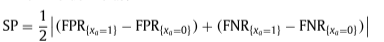

### 深度学习模型

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import torch
import torch.nn as nn
from tab_transformer_pytorch import TabTransformer
from torch.utils.data import DataLoader, TensorDataset, random_split
import torch.optim as optim

#### 加载数据函数

In [11]:
def loader(other_columns,binary_columns,y,batch_size=32):
    # 计算连续特征的均值和标准差 (用于标准化)
    mean = other_columns.mean(axis=0)
    std = other_columns.std(axis=0)
    std[std == 0] = 1e-8  # 避免标准差为 0

    # 数据标准化
    other_columns = (other_columns - mean) / std

    other_columns = torch.tensor(other_columns.values, dtype=torch.float32)
    binary_columns = torch.tensor(binary_columns.values, dtype=torch.long)
    y = torch.tensor(y, dtype=torch.float32)  # 如果是分类问题，y应该是长整型

    # 创建数据集
    dataset = TensorDataset(binary_columns, other_columns, y)

    torch.manual_seed(42)
    # 划分训练集和测试集 (例如 80% 训练集，20% 测试集)
    train_size = int(0.8 * len(dataset))  # 80% 用于训练
    test_size = len(dataset) - train_size  # 剩余部分用于测试
    train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

    # 创建 DataLoader
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    return train_loader,test_loader

#### 自定义损失函数

In [12]:
from sklearn.metrics import confusion_matrix

class CustomLoss(nn.Module):
    def __init__(self, original_loss_fn, lambda_fpr=0.5, col_idx=None, some_value=None,some_value2=None):
        """
        :param original_loss_fn: 原始损失函数（如 BCEWithLogitsLoss）
        :param lambda_fpr: FPR 惩罚项的权重
        :param col_idx: 需要筛选的类别列索引
        :param some_value: 需要筛选的类别取值
        """
        super(CustomLoss, self).__init__()
        self.original_loss_fn = original_loss_fn
        self.lambda_fpr = lambda_fpr
        self.col_idx = col_idx
        self.some_value = some_value
        self.some_value2 = some_value2

    def forward(self, outputs, targets, X_categ_batch):
        # 计算原始损失
        loss = self.original_loss_fn(outputs, targets)

        if self.col_idx is not None and self.some_value is not None and self.some_value2 is not None:
            # 选出 X_categ_batch[:, col_idx] == some_value 的样本索引
            mask = (X_categ_batch[:, self.col_idx] == self.some_value).cpu()
            mask2 = (X_categ_batch[:, self.col_idx] == self.some_value2).cpu()

            if mask.sum() > 0 and mask2.sum()>0:  # 只有当存在符合条件的样本时，才计算 FPR
                # 取出符合条件的样本
                filtered_preds = torch.sigmoid(outputs[mask]) > 0.5
                filtered_targets = targets[mask]
                
                filtered_preds2 = torch.sigmoid(outputs[mask2]) > 0.5
                filtered_targets2 = targets[mask2]
                
                if filtered_preds.numel() == 0 or filtered_preds2.numel() == 0:
                    return loss
                
                cm = confusion_matrix(filtered_targets2.cpu(), filtered_preds2.cpu(),labels=[0, 1])
                cm2 = confusion_matrix(filtered_targets2.cpu(), filtered_preds2.cpu(),labels=[0, 1])
                
                if cm.shape == (1, 1) or cm2.shape == (1, 1):
                    return loss
                
                # 计算混淆矩阵
                tn, fp, fn, tp = cm.ravel()
                tn2, fp2, fn2, tp2 = cm2.ravel()

                # 计算 FPR
                fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
                fpr2 = fp2 / (fp2 + tn2) if (fp2 + tn2) > 0 else 0.0
                
                # 计算 FNR
                fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0
                fnr2 = fn2 / (fn2 + tp2) if (fn2 + tp2) > 0 else 0.0

                # 在损失中加入 FPR 作为惩罚项
                loss += self.lambda_fpr * (torch.abs(torch.tensor(fpr2-fpr))+torch.abs(torch.tensor(fnr2-fnr)))

        return loss

#### 模型设置与训练

In [13]:
def train(train_loader,categories,num_continuous,criterion,num_epochs):
    model = TabTransformer(
    categories=categories,
    num_continuous = num_continuous,                # number of continuous values
    dim = 32,                           # dimension, paper set at 32
    dim_out = 1,                        # binary prediction, but could be anything
    depth = 6,                          # depth, paper recommended 6
    heads = 8,                          # heads, paper recommends 8
    attn_dropout = 0.1,                 # post-attention dropout
    ff_dropout = 0.1,                   # feed forward dropout
    mlp_hidden_mults = (4, 2),          # relative multiples of each hidden dimension of the last mlp to logits
    mlp_act = nn.ReLU(),                # activation for final mlp, defaults to relu, but could be anything else (selu etc)
    #     continuous_mean_std = cont_mean_std # (optional) - normalize the continuous values before layer norm
    )
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    # 定义损失函数（适用于二分类）
    criterion = criterion

    # 定义优化器
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    # 训练循环
    num_epochs = num_epochs
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
    
        for X_categ_batch, X_cont_batch, y_batch in train_loader:
            X_categ_batch, X_cont_batch, y_batch = (
                X_categ_batch.to(device),
                X_cont_batch.to(device),
                y_batch.to(device),
            )

            # 前向传播
            outputs = model(X_categ_batch, X_cont_batch).squeeze()  # 输出 shape: (batch_size,)
            
            if isinstance(criterion, nn.BCEWithLogitsLoss):
                loss = criterion(outputs, y_batch)
            # 计算损失
            else:
                loss = criterion(outputs, y_batch,X_categ_batch) 
    
            # 反向传播和优化
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        # 打印每个 epoch 的损失
        if (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss / len(train_loader):.4f}")
    return model

#### 模型测试

In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score

In [15]:
def test(model,test_loader):
    model.eval()
    # 初始化一些变量来存储预测结果和真实标签
    all_preds = []
    all_labels = []
    all_probs = []
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # 禁用梯度计算，因为我们在测试过程中不需要反向传播
    with torch.no_grad():
        # 遍历测试数据加载器
        for X_categ_batch, X_cont_batch, y_batch in test_loader:
            X_categ_batch, X_cont_batch, y_batch = (
                X_categ_batch.to(device),
                X_cont_batch.to(device),
                y_batch.to(device),
            )

            # 前向传播：得到模型的预测
            outputs = model(X_categ_batch, X_cont_batch).squeeze()
    
            # 对于二分类任务，使用 Sigmoid 作为激活函数（如果没有用）
            preds = torch.round(torch.sigmoid(outputs))
    
            # 保存预测结果和真实标签
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
            all_probs.extend(torch.sigmoid(outputs).cpu().detach().numpy())
    
    
    # 计算各项指标
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    roc_auc = roc_auc_score(all_labels, all_probs)
    auc_pr = average_precision_score(all_labels, all_probs)

    # 打印结果
    print(f"准确率: {accuracy:.2f}")
    print(f"平均精确率: {precision:.2f}")
    print(f"平均召回率: {recall:.2f}")
    print(f"平均F1得分: {f1:.2f}")
    print(f"平均AUC-ROC: {roc_auc:.2f}")
    print(f"平均AUC-PR: {auc_pr:.2f}")

#### 分为连续和分类问题

把序数属性作为连续值

#### Australia

In [66]:
nunique_counts = Australia_X.nunique()
binary_columns = Australia_X.loc[:, nunique_counts == 2]
other_columns = Australia_X.loc[:, nunique_counts > 2]


In [67]:
start = datetime.now()
#加载数据
train_loader,test_loader=loader(other_columns,binary_columns,Australia_y,batch_size=64)
#定义损失函数
custom_loss = CustomLoss(
    original_loss_fn=nn.BCEWithLogitsLoss(),
    lambda_fpr=1.0,   # FPR 惩罚项的权重
    col_idx=0,        # 选择第 2 列类别特征
    some_value=1,      # 只计算该列等于 1 的样本的 FPR
    some_value2=0
)
#训练
model = train(train_loader,(2,2,2,2),10,custom_loss,50)

#测试
test(model,test_loader)
end = datetime.now()
print(f"平均运行时间: {(end - start)}")

Epoch [10/50], Loss: 0.3382
Epoch [20/50], Loss: 0.3041
Epoch [30/50], Loss: 0.2833
Epoch [40/50], Loss: 0.2518
Epoch [50/50], Loss: 0.2373
准确率: 0.85
平均精确率: 0.80
平均召回率: 0.89
平均F1得分: 0.84
平均AUC-ROC: 0.89
平均AUC-PR: 0.81
平均运行时间: 0:00:29.294716


In [61]:
start = datetime.now()
#训练
model = train(train_loader,(2,2,2,2),10,nn.BCEWithLogitsLoss(),50)
#测试
test(model,test_loader)
end = datetime.now()
print(f"平均运行时间: {(end - start)}")

Epoch [10/50], Loss: 0.3346
Epoch [20/50], Loss: 0.3199
Epoch [30/50], Loss: 0.2871
Epoch [40/50], Loss: 0.2624
Epoch [50/50], Loss: 0.2490
准确率: 0.86
平均精确率: 0.81
平均召回率: 0.89
平均F1得分: 0.85
平均AUC-ROC: 0.90
平均AUC-PR: 0.83
平均运行时间: 0:00:14.615456


In [93]:
#平衡后
nunique_counts = Australia_X_res.nunique()
binary_columns = Australia_X_res.loc[:, nunique_counts == 2]
other_columns = Australia_X_res.loc[:, nunique_counts > 2]
start = datetime.now()
#加载数据
train_loader,test_loader=loader(other_columns,binary_columns,Australia_y_res,batch_size=64)
#训练
model = train(train_loader,(2,2,2,2),10,custom_loss,50)
#测试
test(model,test_loader)
end = datetime.now()
print(f"平均运行时间: {(end - start)}")

Epoch [10/50], Loss: 0.3208
Epoch [20/50], Loss: 0.3077
Epoch [30/50], Loss: 0.2736
Epoch [40/50], Loss: 0.2390
Epoch [50/50], Loss: 0.2163
准确率: 0.86
平均精确率: 0.89
平均召回率: 0.86
平均F1得分: 0.87
平均AUC-ROC: 0.93
平均AUC-PR: 0.92
平均运行时间: 0:00:17.173202


In [94]:
start = datetime.now()
#训练
model = train(train_loader,(2,2,2,2),10,nn.BCEWithLogitsLoss(),50)
#测试
test(model,test_loader)
end = datetime.now()
print(f"平均运行时间: {(end - start)}")

Epoch [10/50], Loss: 0.3245
Epoch [20/50], Loss: 0.3164
Epoch [30/50], Loss: 0.2720
Epoch [40/50], Loss: 0.2496
Epoch [50/50], Loss: 0.2134
准确率: 0.87
平均精确率: 0.90
平均召回率: 0.86
平均F1得分: 0.88
平均AUC-ROC: 0.93
平均AUC-PR: 0.92
平均运行时间: 0:00:16.524391


#### German

In [96]:
German_X=German_X.astype(int)
nunique_counts = German_X.nunique()
binary_columns = German_X.loc[:, nunique_counts == 2]
other_columns = German_X.loc[:, nunique_counts > 2]

In [97]:
start = datetime.now()
#加载数据
train_loader,test_loader=loader(other_columns,binary_columns,German_y,batch_size=128)
#定义损失函数
custom_loss = CustomLoss(
    original_loss_fn=nn.BCEWithLogitsLoss(),
    lambda_fpr=1.0,   # FPR 惩罚项的权重
    col_idx=0,        # 选择第 2 列类别特征
    some_value=1,      # 只计算该列等于 1 的样本的 FPR
    some_value2=0
)
#训练
model = train(train_loader,(2,2,2,2,2,2,2,2,2,2,2,2,2,2),13,custom_loss,50)
#测试
test(model,test_loader)
end = datetime.now()
print(f"平均运行时间: {(end - start)}")

Epoch [10/50], Loss: 0.5491
Epoch [20/50], Loss: 0.4749
Epoch [30/50], Loss: 0.4394
Epoch [40/50], Loss: 0.3774
Epoch [50/50], Loss: 0.3391
准确率: 0.71
平均精确率: 0.39
平均召回率: 0.17
平均F1得分: 0.24
平均AUC-ROC: 0.64
平均AUC-PR: 0.40
平均运行时间: 0:00:11.992667


In [98]:
start = datetime.now()
#训练
model = train(train_loader,(2,2,2,2,2,2,2,2,2,2,2,2,2,2),13,nn.BCEWithLogitsLoss(),50)
#测试
test(model,test_loader)
end = datetime.now()
print(f"平均运行时间: {(end - start)}")

Epoch [10/50], Loss: 0.5360
Epoch [20/50], Loss: 0.5021
Epoch [30/50], Loss: 0.4515
Epoch [40/50], Loss: 0.3756
Epoch [50/50], Loss: 0.3413
准确率: 0.69
平均精确率: 0.43
平均召回率: 0.49
平均F1得分: 0.46
平均AUC-ROC: 0.65
平均AUC-PR: 0.41
平均运行时间: 0:00:11.658327


In [104]:
#平衡后
German_X_res=German_X_res.astype(int)
nunique_counts = German_X_res.nunique()
binary_columns = German_X_res.loc[:, nunique_counts == 2]
other_columns = German_X_res.loc[:, nunique_counts > 2]
start = datetime.now()
#加载数据
train_loader,test_loader=loader(other_columns,binary_columns,German_y_res,batch_size=16)
#训练
model = train(train_loader,(2,2,2,2,2,2,2,2,2,2,2,2,2,2),13,custom_loss,50)
#测试
test(model,test_loader)
end = datetime.now()
print(f"平均运行时间: {(end - start)}")

Epoch [10/50], Loss: 0.3706
Epoch [20/50], Loss: 0.3212
Epoch [30/50], Loss: 0.2924
Epoch [40/50], Loss: 0.2499
Epoch [50/50], Loss: 0.2180
准确率: 0.78
平均精确率: 0.78
平均召回率: 0.78
平均F1得分: 0.78
平均AUC-ROC: 0.84
平均AUC-PR: 0.88
平均运行时间: 0:00:29.661760


In [74]:
#平衡后
German_X_res=German_X_res.astype(int)
nunique_counts = German_X_res.nunique()
binary_columns = German_X_res.loc[:, nunique_counts == 2]
other_columns = German_X_res.loc[:, nunique_counts > 2]
#加载数据
train_loader,test_loader=loader(other_columns,binary_columns,German_y_res,batch_size=8)

In [81]:
start = datetime.now()
#训练
model = train(train_loader,(2,2,2,2,2,2,2,2,2,2,2,2,2,2),13,nn.BCEWithLogitsLoss(),20)
#测试
test(model,test_loader)
end = datetime.now()
print(f"平均运行时间: {(end - start)}")

Epoch [10/20], Loss: 0.3853
Epoch [20/20], Loss: 0.3491
准确率: 0.78
平均精确率: 0.84
平均召回率: 0.67
平均F1得分: 0.75
平均AUC-ROC: 0.84
平均AUC-PR: 0.88
平均运行时间: 0:02:27.019444


#### Taiwan

In [106]:
nunique_counts = Taiwan_X.nunique()
binary_columns = Taiwan_X.loc[:, nunique_counts == 2]
other_columns = Taiwan_X.loc[:, nunique_counts > 2]
random_column = np.random.randint(0, 2, size=binary_columns.shape[0])  # 生成 0-1 之间的随机整数
df = pd.DataFrame(random_column, columns=['random_column'])
binary_columns = pd.concat([binary_columns, df], axis=1)

In [108]:
start = datetime.now()
#加载数据
train_loader,test_loader=loader(other_columns,binary_columns,Taiwan_y,batch_size=512)
#定义损失函数
custom_loss = CustomLoss(
    original_loss_fn=nn.BCEWithLogitsLoss(),
    lambda_fpr=1.0,   # FPR 惩罚项的权重
    col_idx=0,        # 选择第 2 列类别特征
    some_value=1,      # 只计算该列等于 1 的样本的 FPR
    some_value2=0
)
#训练
model = train(train_loader,(2,2),22,custom_loss,30)
#测试
test(model,test_loader)
end = datetime.now()
print(f"平均运行时间: {(end - start)}")

Epoch [10/30], Loss: 0.4476
Epoch [20/30], Loss: 0.4311
Epoch [30/30], Loss: 0.4204
准确率: 0.82
平均精确率: 0.67
平均召回率: 0.35
平均F1得分: 0.46
平均AUC-ROC: 0.77
平均AUC-PR: 0.54
平均运行时间: 0:00:53.086662


In [109]:
start = datetime.now()
#训练
model = train(train_loader,(2,2),22,nn.BCEWithLogitsLoss(),30)
#测试
test(model,test_loader)
end = datetime.now()
print(f"平均运行时间: {(end - start)}")

Epoch [10/30], Loss: 0.4451
Epoch [20/30], Loss: 0.4305
Epoch [30/30], Loss: 0.4193
准确率: 0.82
平均精确率: 0.68
平均召回率: 0.35
平均F1得分: 0.47
平均AUC-ROC: 0.76
平均AUC-PR: 0.54
平均运行时间: 0:00:52.557079


In [116]:
#平衡后
nunique_counts = Taiwan_X_res.nunique()
binary_columns = Taiwan_X_res.loc[:, nunique_counts == 2]
other_columns = Taiwan_X_res.loc[:, nunique_counts > 2]
random_column = np.random.randint(0, 2, size=binary_columns.shape[0])  # 生成 0-1 之间的随机整数
df = pd.DataFrame(random_column, columns=['random_column'])
binary_columns = pd.concat([binary_columns, df], axis=1)
start = datetime.now()
#加载数据
train_loader,test_loader=loader(other_columns,binary_columns,Taiwan_y_res,batch_size=2048)
#训练
model = train(train_loader,(2,2),22,custom_loss,80)
#测试
test(model,test_loader)
end = datetime.now()
print(f"平均运行时间: {(end - start)}")

Epoch [10/80], Loss: 0.5785
Epoch [20/80], Loss: 0.5593
Epoch [30/80], Loss: 0.5418
Epoch [40/80], Loss: 0.5129
Epoch [50/80], Loss: 0.4850
Epoch [60/80], Loss: 0.4609
Epoch [70/80], Loss: 0.4403
Epoch [80/80], Loss: 0.4201
准确率: 0.76
平均精确率: 0.77
平均召回率: 0.75
平均F1得分: 0.76
平均AUC-ROC: 0.84
平均AUC-PR: 0.85
平均运行时间: 0:01:34.109550


In [61]:
nunique_counts = Taiwan_X_res.nunique()
binary_columns = Taiwan_X_res.loc[:, nunique_counts == 2]
other_columns = Taiwan_X_res.loc[:, nunique_counts > 2]
# random_column = np.random.randint(0, 2, size=binary_columns.shape[0])  # 生成 0-1 之间的随机整数
random_column = [0] * other_columns.shape[0]
df = pd.DataFrame(random_column, columns=['random_column'])
binary_columns = pd.concat([binary_columns, df], axis=1)
#加载数据
train_loader,test_loader=loader(other_columns,binary_columns,Taiwan_y_res,batch_size=2048)

In [62]:
start = datetime.now()
#训练
model = train(train_loader,(2,2),22,nn.BCEWithLogitsLoss(),80)
#测试
test(model,test_loader)
end = datetime.now()
print(f"平均运行时间: {(end - start)}")

Epoch [10/80], Loss: 0.5779
Epoch [20/80], Loss: 0.5584
Epoch [30/80], Loss: 0.5411
Epoch [40/80], Loss: 0.5120
Epoch [50/80], Loss: 0.4869
Epoch [60/80], Loss: 0.4643
Epoch [70/80], Loss: 0.4468
Epoch [80/80], Loss: 0.4298
准确率: 0.76
平均精确率: 0.76
平均召回率: 0.76
平均F1得分: 0.76
平均AUC-ROC: 0.84
平均AUC-PR: 0.85
平均运行时间: 0:01:25.736608


#### Platform

In [62]:
nunique_counts = Platform_X.nunique()
binary_columns = Platform_X.loc[:, nunique_counts == 2]
other_columns = Platform_X.loc[:, nunique_counts > 2]


In [59]:
start = datetime.now()
#加载数据
train_loader,test_loader=loader(other_columns,binary_columns,Platform_y,batch_size=4096)
#定义损失函数
custom_loss = CustomLoss(
    original_loss_fn=nn.BCEWithLogitsLoss(),
    lambda_fpr=1.0,   # FPR 惩罚项的权重
    col_idx=0,        # 选择第 2 列类别特征
    some_value=1,      # 只计算该列等于 1 的样本的 FPR
    some_value2=0
)
#训练
model = train(train_loader,(2,2,2),36,custom_loss,70)
#测试
test(model,test_loader)
end = datetime.now()
print(f"平均运行时间: {(end - start)}")

Epoch [10/70], Loss: 0.4479
Epoch [20/70], Loss: 0.4423
Epoch [30/70], Loss: 0.4292
Epoch [40/70], Loss: 0.4048
Epoch [50/70], Loss: 0.3817
Epoch [60/70], Loss: 0.3607
Epoch [70/70], Loss: 0.3429
准确率: 0.77
平均精确率: 0.37
平均召回率: 0.19
平均F1得分: 0.25
平均AUC-ROC: 0.64
平均AUC-PR: 0.30
平均运行时间: 0:16:45.321016


In [60]:
start = datetime.now()
#训练
model = train(train_loader,(2,2,2),36,nn.BCEWithLogitsLoss(),70)
#测试
test(model,test_loader)
end = datetime.now()
print(f"平均运行时间: {(end - start)}")

Epoch [10/70], Loss: 0.4476
Epoch [20/70], Loss: 0.4416
Epoch [30/70], Loss: 0.4264
Epoch [40/70], Loss: 0.4015
Epoch [50/70], Loss: 0.3782
Epoch [60/70], Loss: 0.3576
Epoch [70/70], Loss: 0.3408
准确率: 0.77
平均精确率: 0.37
平均召回率: 0.20
平均F1得分: 0.26
平均AUC-ROC: 0.64
平均AUC-PR: 0.30
平均运行时间: 0:16:26.517732


In [ ]:
#平衡后
nunique_counts = Platform_X_res.nunique()
binary_columns = Platform_X_res.loc[:, nunique_counts == 2]
other_columns = Platform_X_res.loc[:, nunique_counts > 2]

In [61]:
start = datetime.now()
#加载数据
train_loader,test_loader=loader(other_columns,binary_columns,Platform_y_res.squeeze(),batch_size=4096)
#训练
model = train(train_loader,(2,2),37,custom_loss,70)
#测试
test(model,test_loader)
end = datetime.now()
print(f"平均运行时间: {(end - start)}")

Epoch [10/70], Loss: 0.4291
Epoch [20/70], Loss: 0.3973
Epoch [30/70], Loss: 0.3844
Epoch [40/70], Loss: 0.3744
Epoch [50/70], Loss: 0.3671
Epoch [60/70], Loss: 0.3626
Epoch [70/70], Loss: 0.3578
准确率: 0.81
平均精确率: 0.88
平均召回率: 0.73
平均F1得分: 0.80
平均AUC-ROC: 0.89
平均AUC-PR: 0.91
平均运行时间: 0:27:28.322736


In [63]:
start = datetime.now()
#训练
model = train(train_loader,(2,2),37,nn.BCEWithLogitsLoss(),90)
#测试
test(model,test_loader)
end = datetime.now()
print(f"平均运行时间: {(end - start)}")

Epoch [10/90], Loss: 0.4293
Epoch [20/90], Loss: 0.3984
Epoch [30/90], Loss: 0.3847
Epoch [40/90], Loss: 0.3759
Epoch [50/90], Loss: 0.3696
Epoch [60/90], Loss: 0.3700
Epoch [70/90], Loss: 0.3624
Epoch [80/90], Loss: 0.3585
Epoch [90/90], Loss: 0.3543
准确率: 0.81
平均精确率: 0.88
平均召回率: 0.73
平均F1得分: 0.80
平均AUC-ROC: 0.89
平均AUC-PR: 0.91
平均运行时间: 0:34:20.973009


In [63]:
def train(train_loader,categories,num_continuous,criterion,num_epochs):
    model = TabTransformer(
    categories=categories,
    num_continuous = num_continuous,                # number of continuous values
    dim = 32,                           # dimension, paper set at 32
    dim_out = 1,                        # binary prediction, but could be anything
    depth = 6,                          # depth, paper recommended 6
    heads = 8,                          # heads, paper recommends 8
    attn_dropout = 0.1,                 # post-attention dropout
    ff_dropout = 0.1,                   # feed forward dropout
    mlp_hidden_mults = (8 ,4, 2),          # relative multiples of each hidden dimension of the last mlp to logits
    mlp_act = nn.ReLU(),                # activation for final mlp, defaults to relu, but could be anything else (selu etc)
    #     continuous_mean_std = cont_mean_std # (optional) - normalize the continuous values before layer norm
    )
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    # 定义损失函数（适用于二分类）
    criterion = criterion

    # 定义优化器
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.2)  # 每 10 轮 lr 降 10 倍

    # 训练循环
    num_epochs = num_epochs
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
    
        for X_categ_batch, X_cont_batch, y_batch in train_loader:
            X_categ_batch, X_cont_batch, y_batch = (
                X_categ_batch.to(device),
                X_cont_batch.to(device),
                y_batch.to(device),
            )

            # 前向传播
            outputs = model(X_categ_batch, X_cont_batch).squeeze()  # 输出 shape: (batch_size,)
            
            if isinstance(criterion, nn.BCEWithLogitsLoss):
                loss = criterion(outputs, y_batch)
            # 计算损失
            else:
                loss = criterion(outputs, y_batch,X_categ_batch) 
    
            # 反向传播和优化
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
        scheduler.step()

        # 打印每个 epoch 的损失
        if (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss / len(train_loader):.4f}")
    return model

In [ ]:
#平衡后
nunique_counts = Platform_X_res.nunique()
binary_columns = Platform_X_res.loc[:, nunique_counts == 2]
other_columns = Platform_X_res.loc[:, nunique_counts > 2]
train_loader,test_loader=loader(other_columns,binary_columns,Platform_y_res.squeeze(),batch_size=1024)
start = datetime.now()
#训练
model = train(train_loader,(2,2),37,nn.BCEWithLogitsLoss(),60)
#测试
test(model,test_loader)
end = datetime.now()
print(f"平均运行时间: {(end - start)}")

In [64]:
#平衡后
nunique_counts = Platform_X_res.nunique()
binary_columns = Platform_X_res.loc[:, nunique_counts == 2]
other_columns = Platform_X_res.loc[:, nunique_counts > 2]
train_loader,test_loader=loader(other_columns,binary_columns,Platform_y_res.squeeze(),batch_size=1024)
start = datetime.now()
#训练
model = train(train_loader,(2,2),37,nn.BCEWithLogitsLoss(),60)
#测试
test(model,test_loader)
end = datetime.now()
print(f"平均运行时间: {(end - start)}")

Epoch [10/60], Loss: 0.3888
Epoch [20/60], Loss: 0.3510
Epoch [30/60], Loss: 0.3378
Epoch [40/60], Loss: 0.3346
Epoch [50/60], Loss: 0.3339
Epoch [60/60], Loss: 0.3338
准确率: 0.82
平均精确率: 0.87
平均召回率: 0.75
平均F1得分: 0.80
平均AUC-ROC: 0.90
平均AUC-PR: 0.92
平均运行时间: 0:41:11.940628


In [65]:
from joblib import dump, load

# 保存模型
dump(model, 'tab_transformer.joblib')


['tab_transformer.joblib']

DeepSHAP

In [66]:
import torch
import pandas as pd

def custom_shap_explainer(model, x_cat, x_cont, cat_names=None, cont_names=None, k=5, baseline_cat=None, baseline_cont=None, target_class=0):
    model.eval()
    device = next(model.parameters()).device

    x_cat = x_cat.to(device)
    x_cont = x_cont.to(device)

    with torch.no_grad():
        base_output = model(x_cat, x_cont)
        if base_output.ndim > 1 and base_output.shape[1] > 1:
            base_output = base_output[:, target_class]
        else:
            base_output = base_output.squeeze()

    # 初始化 baseline
    if baseline_cat is None:
        baseline_cat = torch.zeros_like(x_cat)

    if baseline_cont is None:
        baseline_cont = x_cont.mean(dim=0, keepdim=True).expand_as(x_cont)

    shap_cat = torch.zeros_like(x_cat, dtype=torch.float)
    shap_cont = torch.zeros_like(x_cont)

    for i in range(x_cat.shape[1]):
        x_cat_masked = x_cat.clone()
        x_cat_masked[:, i] = baseline_cat[:, i]
        with torch.no_grad():
            pred_masked = model(x_cat_masked, x_cont)
            if pred_masked.ndim > 1 and pred_masked.shape[1] > 1:
                pred_masked = pred_masked[:, target_class]
            else:
                pred_masked = pred_masked.squeeze()
        shap_cat[:, i] = base_output - pred_masked

    for i in range(x_cont.shape[1]):
        x_cont_masked = x_cont.clone()
        x_cont_masked[:, i] = baseline_cont[:, i]
        with torch.no_grad():
            pred_masked = model(x_cat, x_cont_masked)
            if pred_masked.ndim > 1 and pred_masked.shape[1] > 1:
                pred_masked = pred_masked[:, target_class]
            else:
                pred_masked = pred_masked.squeeze()
        shap_cont[:, i] = base_output - pred_masked

    # 拼接 & 归一化
    shap_all = torch.cat([shap_cat, shap_cont], dim=1)
    shap_all_abs = shap_all.abs()
    shap_all_norm = shap_all / (shap_all_abs.sum(dim=1, keepdim=True) + 1e-8)

    # 处理特征名
    cat_names = cat_names if cat_names is not None else [f"cat_{i}" for i in range(x_cat.shape[1])]
    cont_names = cont_names if cont_names is not None else [f"cont_{i}" for i in range(x_cont.shape[1])]
    feature_names = cat_names + cont_names
    total_features = shap_all.shape[1]  # 实际的特征数量
    feature_names = feature_names[:total_features]  # 防止名字比实际特征多

    results = []
    for i in range(x_cat.shape[0]):  # 遍历每个样本
        shap_vals = shap_all_norm[i]
        topk_idx = torch.topk(shap_vals.abs(), min(k, total_features)).indices
        topk_names = [feature_names[j] for j in topk_idx]
        topk_contrib = shap_vals[topk_idx].cpu().numpy()
        results.append(pd.DataFrame({
            'feature': topk_names,
            'normalized_shap': topk_contrib
        }))

    return results, shap_all, base_output


In [67]:
x_cat, x_cont, _ = next(iter(test_loader))

# 你的特征名（可选）
cat_names = [f"cat_{i}" for i in range(x_cat.shape[1])]
cont_names = [f"cont_{i}" for i in range(x_cont.shape[1])]

results, shap_all, base_output = custom_shap_explainer(
    model, x_cat, x_cont,
    cat_names=cat_names,
    cont_names=cont_names,
    k=5
)

# 查看第一个样本的 Top-K 特征贡献
print(results[0])


   feature  normalized_shap
0  cont_17        -0.251855
1   cont_0        -0.236918
2  cont_12        -0.199389
3   cont_3         0.077829
4   cont_2        -0.035622


In [1]:
import joblib

model = joblib.load('tab_transformer.joblib')


In [2]:
import torch
import pandas as pd

def custom_shap_multi_baseline(
    model,
    x_cat, x_cont,
    cat_names=None, cont_names=None,
    baseline_cat=None, baseline_cont=None,
    target_class=1,
    normalize=True,
    top_k=5
):
    """
    多 baseline 平均版本的 SHAP，增强鲁棒性。
    baseline_cat / cont 支持多个样本（N_baseline x D）
    """
    model.eval()
    device = next(model.parameters()).device

    x_cat = x_cat.to(device)
    x_cont = x_cont.to(device)

    batch_size = x_cat.shape[0]

    with torch.no_grad():
        base_output = model(x_cat, x_cont)
        if base_output.ndim > 1 and base_output.shape[1] > 1:
            base_output = base_output[:, target_class]
        else:
            base_output = base_output.squeeze()

    # baseline：多个样本
    if baseline_cat is None:
        baseline_cat = torch.zeros((1, x_cat.shape[1]), dtype=torch.long).to(device)
    else:
        baseline_cat = baseline_cat.to(device)

    if baseline_cont is None:
        baseline_cont = x_cont.mean(dim=0, keepdim=True).to(device)
    else:
        baseline_cont = baseline_cont.to(device)

    n_baseline = baseline_cat.shape[0]

    shap_cat = torch.zeros_like(x_cat, dtype=torch.float)
    shap_cont = torch.zeros_like(x_cont)

    # 类别变量 SHAP 计算
    for i in range(x_cat.shape[1]):
        total_diff = torch.zeros(batch_size, device=device)
        for b in range(n_baseline):
            x_cat_masked = x_cat.clone()
            x_cat_masked[:, i] = baseline_cat[b, i]
            with torch.no_grad():
                pred_masked = model(x_cat_masked, x_cont)
                if pred_masked.ndim > 1 and pred_masked.shape[1] > 1:
                    pred_masked = pred_masked[:, target_class]
                else:
                    pred_masked = pred_masked.squeeze()
            total_diff += base_output - pred_masked
        shap_cat[:, i] = total_diff / n_baseline

    # 连续变量 SHAP 计算
    for i in range(x_cont.shape[1]):
        total_diff = torch.zeros(batch_size, device=device)
        for b in range(n_baseline):
            x_cont_masked = x_cont.clone()
            x_cont_masked[:, i] = baseline_cont[b, i]
            with torch.no_grad():
                pred_masked = model(x_cat, x_cont_masked)
                if pred_masked.ndim > 1 and pred_masked.shape[1] > 1:
                    pred_masked = pred_masked[:, target_class]
                else:
                    pred_masked = pred_masked.squeeze()
            total_diff += base_output - pred_masked
        shap_cont[:, i] = total_diff / n_baseline

    shap_all = torch.cat([shap_cat, shap_cont], dim=1)

    # 特征名处理
#     cat_names = cat_names if cat_names is not None else [f"cat_{i}" for i in range(x_cat.shape[1])]
#     cont_names = cont_names if cont_names is not None else [f"cont_{i}" for i in range(x_cont.shape[1])]
    cat_names = Platform_X_res.loc[:, nunique_counts == 2].columns.tolist() #可替换为原列名
    cont_names = Platform_X_res.loc[:, nunique_counts > 2].columns.tolist()
    feature_names = cat_names + cont_names

    if normalize:
        shap_all_abs = shap_all.abs()
        shap_all = shap_all / (shap_all_abs.sum(dim=1, keepdim=True) + 1e-8)

    # 每个样本返回 top-k 重要特征
    results = []
    for i in range(batch_size):
        shap_vals = shap_all[i]
        if top_k is not None:
            topk_idx = torch.topk(shap_vals.abs(), min(top_k, shap_vals.shape[0])).indices
        else:
            topk_idx = torch.arange(shap_vals.shape[0])

        sample_df = pd.DataFrame({
            'feature': [feature_names[j] for j in topk_idx],
            'shap_value': shap_vals[topk_idx].cpu().numpy()
        })
        results.append(sample_df)

    return results, shap_all, base_output


In [4]:
import pandas as pd

In [5]:
Platform_X_res=pd.read_csv('Platform_X_res.csv')
Platform_y_res=pd.read_csv('Platform_y_res.csv')

In [7]:
nunique_counts = Platform_X_res.nunique()
binary_columns = Platform_X_res.loc[:, nunique_counts == 2]
binary_columns

,initialListStatus,applicationType
0,0,0
1,1,0
2,0,0
3,1,0
4,0,0
...,...,...
1280775,0,0
1280776,0,0
1280777,0,0
1280778,1,0


In [11]:
nunique_counts = Platform_X_res.nunique()
binary_columns = Platform_X_res.loc[:, nunique_counts == 2]
other_columns = Platform_X_res.loc[:, nunique_counts > 2]
train_loader,test_loader=loader(other_columns,binary_columns,Platform_y_res.squeeze(),batch_size=1024)

# baseline 从训练集选前10个样本
test_cat,test_cont,_=next(iter(test_loader))
test_cat=test_cat[:10]
test_cont=test_cont[:10]
baseline_cat,baseline_cont,_=next(iter(train_loader))
# baseline_cat=baseline_cat[:10]
# baseline_cont=baseline_cont[:10]

results, shap_vals, output = custom_shap_multi_baseline(
    model,
    x_cat=test_cat,  # 待解释样本
    x_cont=test_cont,
    baseline_cat=baseline_cat,
    baseline_cont=baseline_cont,
    target_class=1,
    normalize=True,
    top_k=15
)


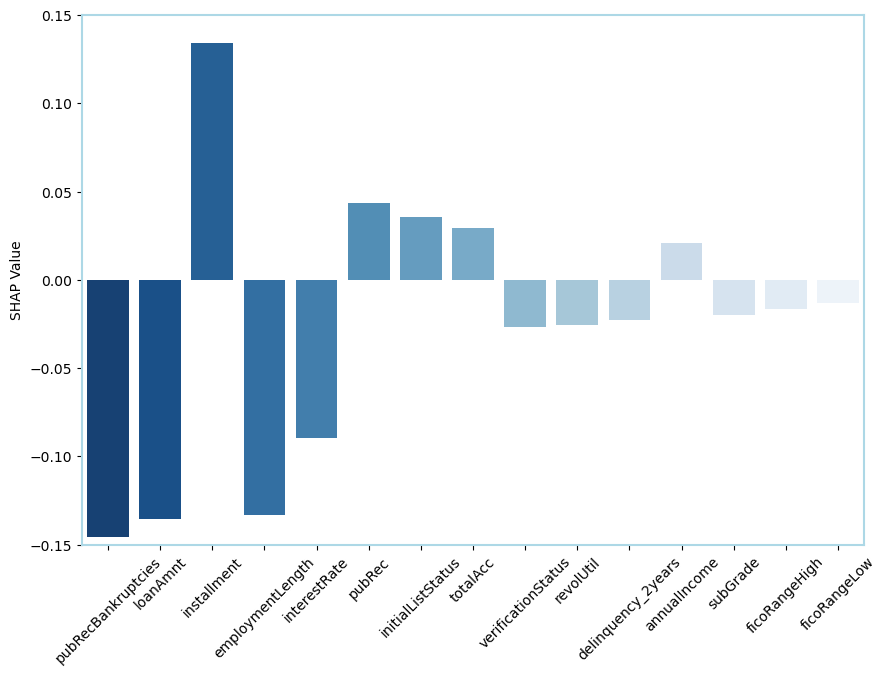

In [38]:
cat_names = Platform_X_res.loc[:, nunique_counts == 2].columns.tolist() #可替换为原列名
cont_names = Platform_X_res.loc[:, nunique_counts > 2].columns.tolist()

import matplotlib.pyplot as plt
import seaborn as sns


def plot_topk_shap(results):
    for i, df in enumerate(results):
        plt.figure(figsize=(9, 7))
        
        # 画柱状图，并设置渐变色调（深到浅）
        ax = sns.barplot(
            x="feature", 
            y="shap_value", 
            data=df, 
            palette=sns.color_palette("Blues", n_colors=len(df))[::-1]
        )

        # 设置图框颜色和粗细
        for spine in ax.spines.values():
            spine.set_edgecolor('#ADD8E6')    # 设置边框颜色
            spine.set_linewidth(1.5)        # 设置边框宽度
        
        plt.xlabel("  ")
        plt.xticks(rotation=45)
        plt.ylabel("SHAP Value")
        plt.tight_layout()
        plt.ylim(-0.15, 0.15)
        plt.savefig("shap_value.png", dpi=300, bbox_inches='tight')
        plt.show()

        

plot_topk_shap(results[0:1])


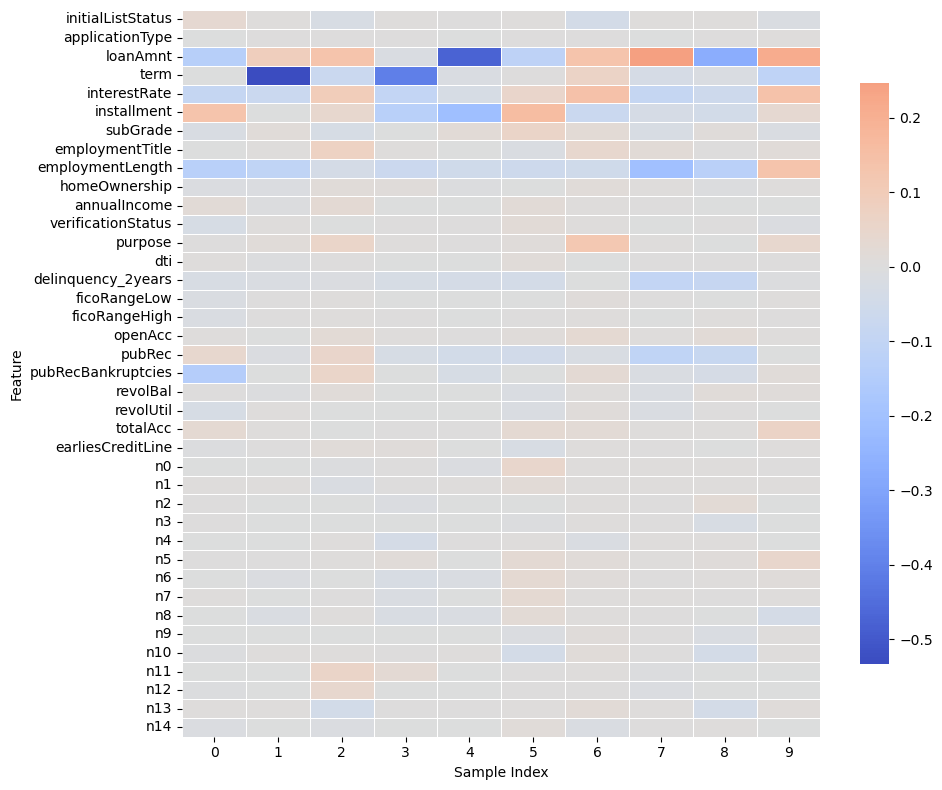

In [41]:
import numpy as np
import pandas as pd


# 转为 DataFrame 后绘图
df_shap = pd.DataFrame(shap_vals.cpu().numpy(), columns=cat_names + cont_names)

plt.figure(figsize=(10, 8), facecolor='white')  # 设置整个图的背景为白色
ax = sns.heatmap(df_shap.T, cmap="coolwarm", center=0, annot=False)

# 设置绘图区域背景为白色
ax.set_facecolor('white')

plt.xlabel("Sample Index")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("heatmap.png", dpi=300, bbox_inches='tight')
plt.show()



In [73]:
import os
import time
import torch
from torch import nn
from multiprocessing import Process
import flwr as fl

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [76]:
# 定义 TabTransformer 模型结构
def get_model():
    model = TabTransformer(
    categories=categories,
    num_continuous = num_continuous,                # number of continuous values
    dim = 32,                           # dimension, paper set at 32
    dim_out = 1,                        # binary prediction, but could be anything
    depth = 6,                          # depth, paper recommended 6
    heads = 8,                          # heads, paper recommends 8
    attn_dropout = 0.1,                 # post-attention dropout
    ff_dropout = 0.1,                   # feed forward dropout
    mlp_hidden_mults = (8 ,4, 2),          # relative multiples of each hidden dimension of the last mlp to logits
    mlp_act = nn.ReLU(),                # activation for final mlp, defaults to relu, but could be anything else (selu etc)
    #     continuous_mean_std = cont_mean_std # (optional) - normalize the continuous values before layer norm
    )
    return model


In [78]:
def start_server():
    strategy = SaveModelStrategy()
    fl.server.start_server(
        server_address="localhost:8083",
        config=fl.server.ServerConfig(num_rounds=1),
        strategy=strategy
    )
    print("✅ Server finished training")

    if strategy.final_parameters is not None:
        torch.save(strategy.final_parameters, "final_params.pth")

In [79]:
from flwr.common import Parameters
from flwr.server.strategy import FedAvg

class SaveModelStrategy(FedAvg):
    def __init__(self,**kwargs):
        super().__init__(**kwargs)
        self.final_parameters = None

    def aggregate_fit(self, server_round, results, failures):
        # 调用父类聚合方法
        aggregated_parameters = super().aggregate_fit(server_round, results, failures)
        
        if aggregated_parameters is not None:
            # 转换为正确的 Parameters 对象
            self.final_parameters = Parameters(
                tensors=aggregated_parameters[0].tensors,
                tensor_type="numpy.ndarray"
            )
        return aggregated_parameters

def start_server():
    strategy = SaveModelStrategy()
    fl.server.start_server(
        server_address="localhost:8083",
        config=fl.server.ServerConfig(num_rounds=1),
        strategy=strategy
    )
    print("✅ Server finished training")

    if strategy.final_parameters is not None:
        # 保存 Parameters 对象
        torch.save(strategy.final_parameters, "final_params.pth")

In [80]:
from collections import OrderedDict

class FlowerClient(fl.client.NumPyClient):
    def __init__(self, train_loader, categories, num_continuous, criterion, num_epochs):
        self.train_loader = train_loader
        self.categories = categories
        self.num_continuous = num_continuous
        self.criterion = criterion
        self.num_epochs = num_epochs
        self.model = get_model().to(device)

    def get_parameters(self, config=None):
        return [val.cpu().numpy() for _, val in self.model.state_dict().items()]

    def set_parameters(self, parameters):
        params_dict = zip(self.model.state_dict().keys(), parameters)
        state_dict = OrderedDict({k: torch.tensor(v) for k, v in params_dict})
        self.model.load_state_dict(state_dict, strict=True)

    def fit(self, parameters, config):
        self.set_parameters(parameters)
        self.model.train()
        optimizer = torch.optim.Adam(self.model.parameters(), lr=1e-3)
        for epoch in range(self.num_epochs):
            for X_cat, X_cont, y in self.train_loader:
                X_cat, X_cont, y = X_cat.to(device), X_cont.to(device), y.to(device)
                optimizer.zero_grad()
                outputs = self.model(X_cat, X_cont).squeeze()
                loss = self.criterion(outputs, y)
                loss.backward()
                optimizer.step()
        return self.get_parameters(), len(self.train_loader.dataset), {}

    def evaluate(self, parameters, config):
        return 0.0, len(self.train_loader.dataset), {}

def start_client(train_loader, categories, num_continuous, criterion, num_epochs):
    client = FlowerClient(train_loader, categories, num_continuous, criterion, num_epochs)
    fl.client.start_numpy_client(server_address="localhost:8083", client=client)


In [81]:
from torch.utils.data import random_split

dataset = train_loader.dataset  # 你自己的数据集
lengths = [int(len(dataset) / 3)] * 2 + [len(dataset) - 2 * int(len(dataset) / 3)]
client_datasets = random_split(dataset, lengths)
# 假设 batch_size 是你想要的批量大小
batch_size = 64

# 用列表推导重新包装为 dataloader
client_loaders = [DataLoader(ds, batch_size=batch_size, shuffle=True) for ds in client_datasets]


num_clients = 3

# 启动 server
server_process = Process(target=start_server)
server_process.start()

# 等待 server 启动
time.sleep(2)

# 启动多个客户端
clients = []
for i in range(num_clients):
    p = Process(
        target=start_client,
        args=(client_loaders[i], (2,2),37,nn.BCEWithLogitsLoss(),60)
    )
    p.start()
    clients.append(p)

# 等待所有客户端结束
for p in clients:
    p.join()

# 等待 server 结束
server_process.join()


	Instead, use the `flower-superlink` CLI command to start a SuperLink as shown below:

		$ flower-superlink --insecure

	To view usage and all available options, run:

		$ flower-superlink --help

	Using `start_server()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower server, config: num_rounds=1, no round_timeout
INFO :      Flower ECE: gRPC server running (1 rounds), SSL is disabled
INFO :      [INIT]
INFO :      Requesting initial parameters from one random client
Process Process-2:
Process Process-3:
Traceback (most recent call last):
Traceback (most recent call last):
  File "/nfs/home/4001_tengyishu/anaconda3/lib/python3.11/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/nfs/home/4001_tengyishu/anaconda3/lib/python3.11/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/tmp/ipykernel_2193

KeyboardInterrupt: 

INFO :      Flower server terminated gracefully.


In [ ]:
import os
import torch
import numpy as np
from flwr.common import Parameters, parameters_to_ndarrays
# 允许加载 Flower 的 Parameters 类型
torch.serialization.add_safe_globals([Parameters])
if os.path.exists("final_params.pth"):
    try:
        loaded = torch.load("final_params.pth")
        
        # 处理两种可能性：元组或 Parameters 对象
        if isinstance(loaded, tuple):
            # 如果是元组，手动构造 Parameters 对象
            flower_params = Parameters(
                tensors=[t.numpy() if torch.is_tensor(t) else t for t in loaded],
                tensor_type="numpy.ndarray"
            )
        elif isinstance(loaded, Parameters):
            flower_params = loaded
        else:
            raise ValueError("未知的参数格式")

        # 转换为 NumPy 数组
        numpy_arrays = parameters_to_ndarrays(flower_params)
        
        # 转换为 PyTorch Tensor
        state_dict = {
            k: torch.from_numpy(v) if isinstance(v, np.ndarray) else v
            for k, v in zip(global_model.state_dict().keys(), numpy_arrays)
        }
        
        global_model.load_state_dict(state_dict, strict=False)
        torch.save(global_model.state_dict(), "global_model.pth")
        print("🌍 Global model saved to global_model.pth")
        
    except Exception as e:
        print(f"⚠️ 加载参数失败: {str(e)}")
else:
    print("⚠️ 未找到 final_params.pth")


In [ ]:
model = get_model().to(device)
model.load_state_dict(torch.load("global_model.pth"))
model.eval()  # 设置为评估模式
test(model,test_loader)

In [37]:
! python federal_learning.py


	Instead, use the `flower-superlink` CLI command to start a SuperLink as shown below:

		$ flower-superlink --insecure

	To view usage and all available options, run:

		$ flower-superlink --help

	Using `start_server()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower server, config: num_rounds=5, no round_timeout
INFO :      Flower ECE: gRPC server running (5 rounds), SSL is disabled
INFO :      [INIT]
INFO :      Requesting initial parameters from one random client
	Instead, use `flwr.client.start_client()` by ensuring you first call the `.to_client()` method as shown below: 
	flwr.client.start_client(
		server_address='<IP>:<PORT>',
		client=FlowerClient().to_client(), # <-- where FlowerClient is of type flwr.client.NumPyClient object
	)
	Using `start_numpy_client()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in f

INFO :      Sent reply
INFO :      Sent reply
INFO :      Sent reply
INFO :      aggregate_fit: received 3 results and 0 failures
INFO :      configure_evaluate: strategy sampled 3 clients (out of 3)
INFO :      
INFO :      Received: evaluate message a74f1440-4f8c-40c3-b57d-152011862cfc
INFO :      
INFO :      Received: evaluate message e9db7fd1-fd4d-4e89-bfba-88fd8212771a
INFO :      
INFO :      Received: evaluate message fd095fb1-62ba-4d0f-9803-baa032a75d73
INFO :      Sent reply
INFO :      Sent reply
INFO :      Sent reply
INFO :      aggregate_evaluate: received 3 results and 0 failures
INFO :      
INFO :      [SUMMARY]
INFO :      Run finished 5 round(s) in 4530.18s
INFO :      	History (loss, distributed):
INFO :      		round 1: 0.0
INFO :      		round 2: 0.0
INFO :      		round 3: 0.0
INFO :      		round 4: 0.0
INFO :      		round 5: 0.0
INFO :      
INFO :      
INFO :      Received: reconnect message ccccc82f-33a4-4a77-9915-aa11278228f7
INFO :      
INFO :      Received: 

0.63/0.61，0.60/0.59，0.58/0.56，0.60/0.68，0.63/0.74，0.60/0.59，0.68/0.75，0.69/0.75，0.66/0.80，0.69/0.73，0.65/0.76，0.75